<a href="https://www.kaggle.com/code/traininglearningwork/scrupulous-data-wrangling?scriptVersionId=237267835" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

# <span style="color:#30BFBF; background-color:#D3D3D3; padding:6px 12px; border-radius:8px;">📘 Introduction</span>

<p style="font-size: 18px;">In this analysis, I primarily focused on data wrangling, as many papers on this dataset have drawn <span style="font-weight:bold;">absurd</span> &#128558; conclusions due to the lack of proper wrangling, such as:</p>
<ul style="font-size: 18px;">
  <li>The top-selling items being things like <span style="color:red; font-weight:bold;">BANK CHARGES</span>, <span style="color:red; font-weight:bold;">CARRIAGE</span>, etc.</li>
  <li>The author being surprised that the cost of <span style="color:red; font-weight:bold;">POSTAGE</span> had doubled during the pre-Christmas season.</li>
</ul>
<p style="font-size: 18px;">
Therefore, before making such bold claims and performing serious analysis <strong>it is important to perform preprocessing:</strong>
</p>

<ul style="font-size: 18px;">
  <li><strong>Check the data types</strong></li>
  <li><strong>Handle missing values</strong></li>
  <li><strong>Remove outliers</strong></li>
  <li><strong>Exclude canceled orders</strong></li>
  <li><strong>Analyze product and non-product items</strong></li>
  <li><strong>Standardize the product assortment data</strong></li>
</ul>
<p style="font-size: 18px;">
<p style="font-size: 18px;">
<p style="font-size: 18px;">    
Only after completing all these data cleaning steps can we proceed to analyzing <strong><em style="color: gray;">data distribution</em></strong>, identifying <strong><em style="color: gray;">correlations between variables (correlation matrix)</em></strong>, analyzing <strong><em style="color: gray;">time series</em></strong> (to identify trends), <strong><em style="color: gray;">customer segmentation (RFM analysis)</em></strong>, and <strong><em style="color: gray;">product categorization (ABC-XYZ analysis)</em></strong>, as well as creating <strong><em style="color: gray;">machine learning models (ML)</em></strong> for demand forecasting or generating recommendations based on preferences</p>

<p style="font-size: 18px;">    
Otherwise, we will face false conclusions, reduced model quality, reproducibility issues, loss of trust in the results, and the inability to correctly compare data.
</p>
</p>


# <span style="color:#30BFBF; background-color:#D3D3D3; padding:6px 12px; border-radius:8px;">📦 About Dataset</span>

<details>
  <summary style="display: flex; justify-content: center; align-items: center;">
    <p style="font-size: 16px; margin-right: 10px;">Description of the data:</p>
    <span class="custom-arrow">▼</span>
  </summary>

  <ul>
    <li>
      <strong>InvoiceNo</strong>: Invoice number.
      <br><em>Nominal</em>, a 6-digit integral number uniquely assigned to each transaction.  
      If this code starts with the letter 'C', it indicates a cancellation.
    </li>
    <li>
      <strong>StockCode</strong>: Product (item) code.
      <br><em>Nominal</em>, a 5-digit integral number uniquely assigned to each distinct product.
    </li>
    <li>
      <strong>Description</strong>: Product (item) name.
      <br><em>Nominal</em>.
    </li>
    <li>
      <strong>Quantity</strong>: The quantities of each product (item) per transaction.
      <br><em>Numeric</em>.
    </li>
    <li>
      <strong>InvoiceDate</strong>: Invoice date and time.
      <br><em>Numeric</em>. The day and time when each transaction was generated.
    </li>
    <li>
      <strong>UnitPrice</strong>: Unit price.
      <br><em>Numeric</em>. Product price per unit in sterling.
    </li>
    <li>
      <strong>CustomerID</strong>: Customer number.
      <br><em>Nominal</em>. A 5-digit integral number uniquely assigned to each customer.
    </li>
    <li>
      <strong>Country</strong>: Country name.
      <br><em>Nominal</em>. The name of the country where each customer resides.
    </li>
  </ul>
</details>

<style>
  details summary {
    list-style: none;
    cursor: pointer;
  }
  .custom-arrow {
    font-size: 18px;
    margin-left: 10px;
  }
  details[open] .custom-arrow {
    transform: rotate(180deg);
  }
</style>


# <span style="color:#30BFBF; background-color:#D3D3D3; padding:6px 12px; border-radius:8px;">🛠️ Preprocessing</span>

## <span style="color:#4B0082; "> • Import required Modules</span>

In [1]:
    !pip install openpyxl
    import pandas as pd
    import numpy as np
    import matplotlib.pyplot as plt
    import seaborn as sns
    import random
    import re
    from sklearn.preprocessing import StandardScaler
    from sklearn.cluster import KMeans

## <span style="color:#4B0082; "> • Dataset loading</span>

In [2]:
df = pd.read_csv('/kaggle/input/online-retail-dataset/online_retail.csv', encoding='latin1')
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


## <span style="color:#4B0082; "> • Original data types</span>

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


## <span style="color:#4B0082; "> • Missing values in the row data</span>

In [4]:
# Count the number of missing values in each column
missing_data = df.isnull().sum()

# Keep only the columns with more than 0 missing values
missing_data = missing_data[missing_data > 0]

# Print the result without data type information
print(missing_data.to_string())

Description      1454
CustomerID     135080


## <span style="color:#4B0082; "> • Data type conversion</span>

<p style="font-size: 16px;">
Convert the data type of <strong>CustomerID</strong> from <em>float</em> to <em>Int64</em> (with a capital letter, as this type supports NaN), and then to <em>string</em>. Missing values will be replaced with "&lt;NA&gt;"
</p>

<p style="font-size: 16px;">
  Convert the <strong>InvoiceDate</strong> column data type to <em>datetime</em>
</p>

In [5]:
# Convert the date to datetime format
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

# Convert CustomerID to Int64 type, supporting NaN, and then to string
df['CustomerID'] = df['CustomerID'].astype('Int64')
df['CustomerID'] = df['CustomerID'].astype('str')


In [6]:
# InvoiceDate and CustomerID data types
print(df[['InvoiceDate', 'CustomerID']].info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 2 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceDate  541909 non-null  datetime64[ns]
 1   CustomerID   541909 non-null  object        
dtypes: datetime64[ns](1), object(1)
memory usage: 8.3+ MB
None


## <span style="color:#4B0082; "> • Missing values after data type conversion</span>

<p style="font-size: 16px;">
  When the <strong>CustomerID</strong> column was converted from <em>Int64</em> to <em>str</em>, NaN values were replaced with the string "&lt;NA&gt;", causing them to no longer appear as missing values.
</p>


In [7]:
# Count the number of rows where CustomerID is '<NA>
NA_count = (df['CustomerID'] == "<NA>").sum()
print("Number of '<NA>' values in CustomerID:", NA_count)

Number of '<NA>' values in CustomerID: 135080


## <span style="color:#4B0082; "> • Replace "NA" in CustomerID with the InvoiceNo</span>

<p style="font-size: 16px;">
  Replace cells in the <strong>CustomerID</strong> column containing "&lt;NA&gt;" with the corresponding values from the <strong>InvoiceNo</strong>.
</p>

<p style="font-size: 16px;">
  This ensures that each order remains intact for subsequent analysis.
</p>


In [8]:
df.loc[df['CustomerID'] == '<NA>', 'CustomerID'] = df['InvoiceNo']

## <span style="color:#4B0082; "> • Removing missing values from the Description column</span>

<p style="font-size: 16px;">
  Deleting rows with missing values in the <strong>Description</strong> column. In the rows with missing <strong>Description</strong> values, the price or quantity of items is zero or negative. 
  These rows can be removed.
</p>

In [9]:
# Deleting rows with missing values in the 'Description' column
df = df.dropna(subset=['Description'])

## <span style="color:#4B0082; "> • Statistics on the raw data</span>

<p style="font-size: 16px;">
  Calculate basic statistics on the original data.
</p>

In [10]:
# Descriptive statistics for numerical columns
numerical_stats = df.select_dtypes(include=['number']).describe()

# Statistics for string and categorical data
categorical_stats = df.select_dtypes(include=['object']).nunique()

# Minimum and maximum date for datetime columns
datetime_stats = df.select_dtypes(include=['datetime']).agg(['min', 'max'])

# Statistics for missing values
missing_data = df.isnull().sum()

# Mean values for numerical columns
mean_values = df.select_dtypes(include=['number']).mean()

# Median values for numerical columns
median_values = df.select_dtypes(include=['number']).median()

# Standard deviation for numerical columns
std_deviation = df.select_dtypes(include=['number']).std()

# Print statistics
print("Descriptive statistics for numerical columns:")
print(numerical_stats)
print("\nNumber of unique values for categorical columns:")
print(categorical_stats)
if not datetime_stats.empty:
    print("\nStatistics for dates:")
    print(datetime_stats)
print("\nNumber of missing values:")
print(missing_data)
print("\nMean values for numerical columns:")
print(mean_values)
print("\nMedian values for numerical columns:")
print(median_values)
print("\nStandard deviation for numerical columns:")
print(std_deviation)


Descriptive statistics for numerical columns:
            Quantity      UnitPrice
count  540455.000000  540455.000000
mean        9.603129       4.623519
std       218.007598      96.889628
min    -80995.000000  -11062.060000
25%         1.000000       1.250000
50%         3.000000       2.080000
75%        10.000000       4.130000
max     80995.000000   38970.000000

Number of unique values for categorical columns:
InvoiceNo      24446
StockCode       3958
Description     4223
CustomerID      6628
Country           38
dtype: int64

Statistics for dates:
            InvoiceDate
min 2010-12-01 08:26:00
max 2011-12-09 12:50:00

Number of missing values:
InvoiceNo      0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
UnitPrice      0
CustomerID     0
Country        0
dtype: int64

Mean values for numerical columns:
Quantity     9.603129
UnitPrice    4.623519
dtype: float64

Median values for numerical columns:
Quantity     3.00
UnitPrice    2.08
dtype: float64

Standa

## <span style="color:#4B0082; "> • Removal of canceled orders</span>

<p style="font-size: 16px;">
  We remove rows where the <strong>InvoiceNo</strong> starts with "C" because these represent canceled orders, which are not relevant for analysis of completed transactions.
</p>

In [11]:
# Deleting all rows where InvoiceNo starts with 'C'
df = df[~df['InvoiceNo'].str.startswith('C')]

# Display the updated DataFrame
print(df)  # Display the new shape of the DataFrame to confirm the changes

       InvoiceNo StockCode                          Description  Quantity  \
0         536365    85123A   WHITE HANGING HEART T-LIGHT HOLDER         6   
1         536365     71053                  WHITE METAL LANTERN         6   
2         536365    84406B       CREAM CUPID HEARTS COAT HANGER         8   
3         536365    84029G  KNITTED UNION FLAG HOT WATER BOTTLE         6   
4         536365    84029E       RED WOOLLY HOTTIE WHITE HEART.         6   
...          ...       ...                                  ...       ...   
541904    581587     22613          PACK OF 20 SPACEBOY NAPKINS        12   
541905    581587     22899         CHILDREN'S APRON DOLLY GIRL          6   
541906    581587     23254        CHILDRENS CUTLERY DOLLY GIRL          4   
541907    581587     23255      CHILDRENS CUTLERY CIRCUS PARADE         4   
541908    581587     22138        BAKING SET 9 PIECE RETROSPOT          3   

               InvoiceDate  UnitPrice CustomerID         Country  
0      2

## <span style="color:#4B0082; "> • Removal of outliers in Quantity</span>

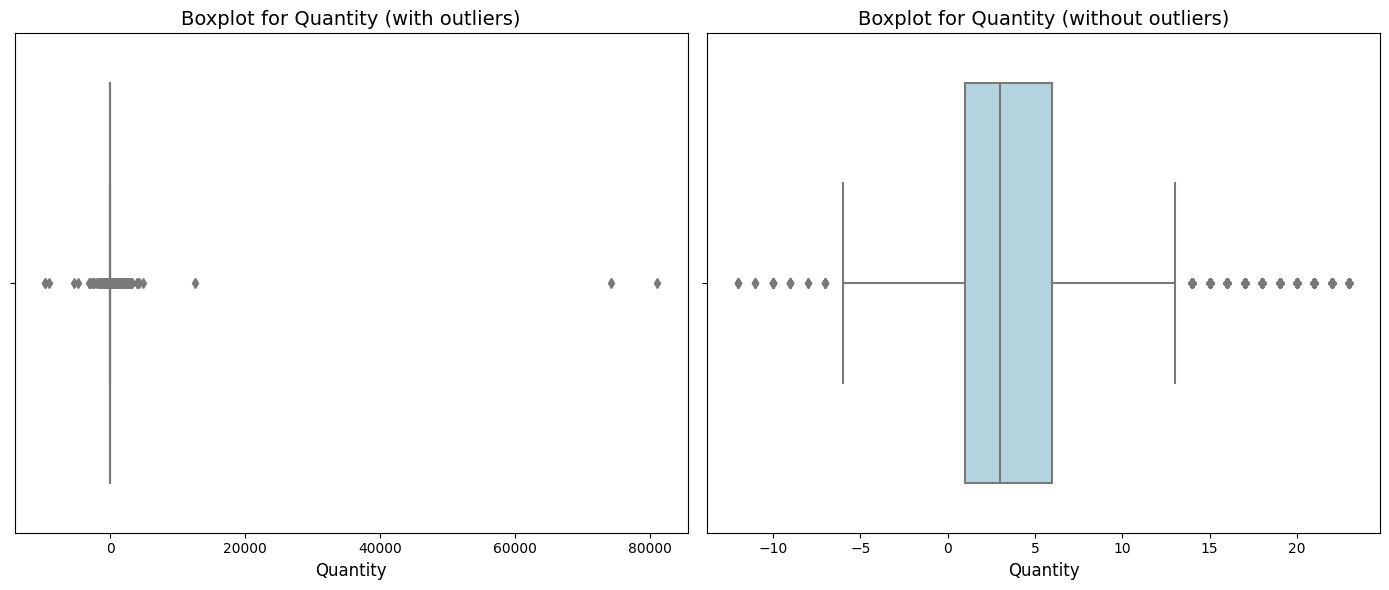

In [12]:
# Boxplot for the Quantity column (with outliers)
plt.figure(figsize=(14, 6))

# Plot 1: Boxplot for Quantity (with outliers)
plt.subplot(1, 2, 1)  # 1 row, 2 columns, 1st plot
sns.boxplot(x=df['Quantity'], color='lightblue')
plt.title('Boxplot for Quantity (with outliers)', fontsize=14)
plt.xlabel('Quantity', fontsize=12)

# Specify columns from which to remove outliers
columns = ['Quantity']

for col in columns:
    Q1 = df[col].quantile(0.25)  # First quartile (25%)
    Q3 = df[col].quantile(0.75)  # Third quartile (75%)
    IQR = Q3 - Q1  # Interquartile range
    lower_bound = Q1 - 1.5 * IQR  # Lower outlier bound
    upper_bound = Q3 + 1.5 * IQR  # Upper outlier bound

    # Filter rows where values are within bounds
    df = df[(df[col] >= lower_bound) & (df[col] <= upper_bound)]

# Boxplot for the Quantity column (without outliers)
plt.subplot(1, 2, 2)  # 1 row, 2 columns, 2nd plot
sns.boxplot(x=df['Quantity'], color='lightblue')
plt.title('Boxplot for Quantity (without outliers)', fontsize=14)
plt.xlabel('Quantity', fontsize=12)

plt.tight_layout()
plt.show()


## <span style="color:#4B0082; "> • Removal of outliers in UnitPrice</span>

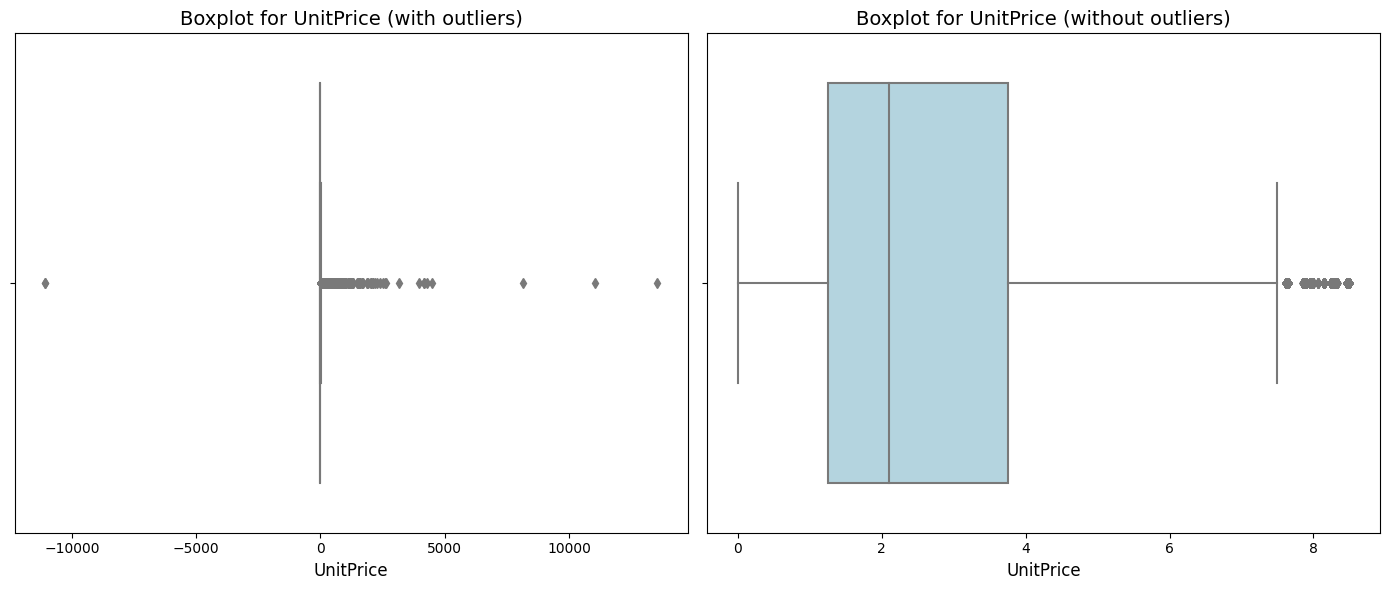

In [13]:
# Boxplot for the UnitPrice column (with outliers)
plt.figure(figsize=(14, 6))

# Plot 1: Boxplot for UnitPrice (with outliers)
plt.subplot(1, 2, 1)  # 1 row, 2 columns, 1st plot
sns.boxplot(x=df['UnitPrice'], color='lightblue')
plt.title('Boxplot for UnitPrice (with outliers)', fontsize=14)
plt.xlabel('UnitPrice', fontsize=12)

# Specify columns from which to remove outliers
columns = ['UnitPrice']

for col in columns:
    Q1 = df[col].quantile(0.25)  # First quartile (25%)
    Q3 = df[col].quantile(0.75)  # Third quartile (75%)
    IQR = Q3 - Q1  # Interquartile range
    lower_bound = Q1 - 1.5 * IQR  # Lower outlier bound
    upper_bound = Q3 + 1.5 * IQR  # Upper outlier bound

    # Filter rows where values are within bounds
    df = df[(df[col] >= lower_bound) & (df[col] <= upper_bound)]

# Plot 2: Boxplot for UnitPrice (without outliers)
plt.subplot(1, 2, 2)  # 1 row, 2 columns, 2nd plot
sns.boxplot(x=df['UnitPrice'], color='lightblue')
plt.title('Boxplot for UnitPrice (without outliers)', fontsize=14)
plt.xlabel('UnitPrice', fontsize=12)

plt.tight_layout()
plt.show()


## <span style="color:#4B0082; "> • Eliminating discrepancies between Description and StockCode</span>

<p style="font-size: 16px;">
  <strong>Description</strong> and <strong>StockCode</strong> should have a complete correspondence with each other. However, in 16.4% of cases, we see different Descriptions for the same StockCode.
</p>


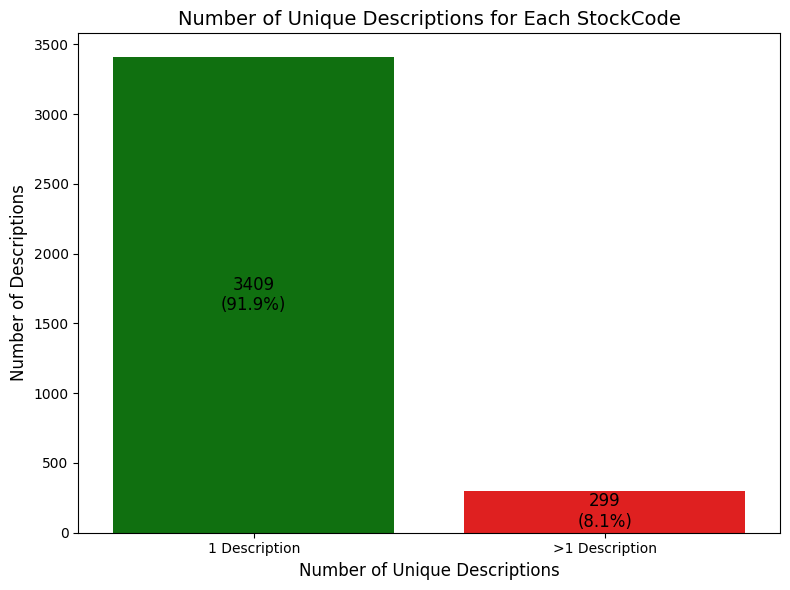

In [14]:
# Counting the number of unique Descriptions for each StockCode
stockcode_description_check = df.groupby('StockCode')['Description'].nunique()

# Counting the number of StockCodes with 1 unique Description and more than 1 Description
single_description_count = (stockcode_description_check == 1).sum()
multiple_descriptions_count = (stockcode_description_check > 1).sum()

# Calculating percentages
total_count = single_description_count + multiple_descriptions_count
single_description_percentage = (single_description_count / total_count) * 100
multiple_descriptions_percentage = (multiple_descriptions_count / total_count) * 100

# Creating a DataFrame for visualization
description_summary = pd.DataFrame({
    'Category': ['1 Description', '>1 Description'],
    'Count': [single_description_count, multiple_descriptions_count],
    'Percentage': [single_description_percentage, multiple_descriptions_percentage]
})

# Visualization
plt.figure(figsize=(8, 6))
bars = sns.barplot(x='Category', y='Count', data=description_summary, palette=['green', 'red'])

# Adding labels inside the bars
for i, bar in enumerate(bars.patches):
    count = description_summary['Count'].iloc[i]
    percentage = description_summary['Percentage'].iloc[i]
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height() / 2,
             f'{count}\n({percentage:.1f}%)', ha='center', va='center', color='black', fontsize=12)

# Chart settings
plt.title('Number of Unique Descriptions for Each StockCode', fontsize=14)
plt.xlabel('Number of Unique Descriptions', fontsize=12)  # X-axis label updated
plt.ylabel('Number of Descriptions', fontsize=12)
plt.tight_layout()
plt.show()


<p style="font-size: 16px;">
  We can see that 8.1% of <strong>StockCodes</strong> have more than one unique <strong>Description</strong>.
</p>

<p style="font-size: 16px;">
  This discrepancy will be resolved after <em>filtering the Description column by case sensitivity</em>.
</p>

## <span style="color:#4B0082; "> • Filtering the Description column by case sensitivity</span>

<em>(product_entries - non_product_entries)</em>

<p style="font-size: 16px;">
  In this dataset, product items are predominantly listed in uppercase in the <strong>Description</strong> column. There are some exceptions that are specifically included in the code to ensure they are captured in the correct sample (e.g., 'TRADITIONAl' with a lowercase 'l' in the cell '3 TRADITIONAl BISCUIT CUTTERS SET').
</p>

<p style="font-size: 16px;">
  Sometimes, non-product items are also listed in uppercase—such as operational receipts and expenses (marketplace fees like 'AMAZON FEE', bank charges like 'BANK CHARGES', postal costs like 'DOTCOM POSTAGE', etc.), which have also been added to a separate list of exclusions.
</p>

In [15]:
def has_lowercase(description):
    has_lower = bool(re.search(r'[a-z]', description))

    # Exceptions for strings with lowercase, which should still be included in the uppercase file
    exceptions_to_lower = (
        'cm' in description or
        'CM' in description or
        '125g' in description or
        '500g' in description or
        '250g' in description or
        '3.5g' in description or
        'TRADITIONAl' in description or
        'No' in description or
        'pack' in description or
        '''Dr. Jam's Arouzer Stress Ball''' in description or
        '''Dad's Cab Electronic Meter''' in description or
        'Boombox Ipod Classic' in description or
        'BLACK BAROQUE CARRIAGE CLOCK' in description or
        'FRENCH CARRIAGE LANTERN' in description or
        'BLACK BAROQUE CARRIAGE CLOCK' in description or
        'USB Office Mirror Ball' in description
    )

    # Exceptions for strings with uppercase, which should still be included in the lowercase file
    exceptions_to_upper = (
        'POSTAGE' in description or
        'CARRIAGE' in description or
        'AMAZON' in description or
        'CHARGES' in description or
        'POSSIBLE DAMAGES OR LOST' in description or
        'ERROR' in description or
        'CREDIT' in description or
        '?' in description or
        '??' in description or
        '???' in description or
        '?missing' in description or
        'missing' in description or
        '?lost' in description or
        'lost'in description or
        'check' in description or
        'rcvd' in description or
        'MIA' in description or
        'Не задано' in description or
        'SAMPLES' in description
    )

    # is_uppercase = description.isupper()
    is_uppercase = description.isupper() and '?' not in description

    return (has_lower and not exceptions_to_lower) or (is_uppercase and exceptions_to_upper)

non_product_entries = df[df['Description'].apply(has_lowercase)].copy()
product_entries = df[~df['Description'].apply(has_lowercase)].copy()

## <span style="color:#4B0082; "> • Creating a single unique Description for each StockCode</span>

In [16]:
# Get unique Descriptions for each StockCode
stockcode_unique_description = product_entries.groupby('StockCode')['Description'].unique().apply(lambda x: x[0]).reset_index()

# Map the unique Descriptions back to the DataFrame
product_entries['Description'] = product_entries['StockCode'].map(stockcode_unique_description.set_index('StockCode')['Description'])

## <span style="color:#4B0082; "> • Statistics on the cleaned data</span>

In [17]:
# Descriptive statistics for numerical columns
numerical_stats = df.describe()

# Statistics for unique values in categorical columns
categorical_stats = df.select_dtypes(include=['object']).nunique()

# Statistics for missing values
missing_data = df.isnull().sum()

# Mean values for numerical columns (fixed with numeric_only=True)
mean_values = df.mean(numeric_only=True)

# Median for numerical columns
median_values = df.median(numeric_only=True)

# Standard deviation for numerical columns
std_deviation = df.std(numeric_only=True)

# Output statistics
print("Descriptive statistics for numerical columns:")
print(numerical_stats)
print("\nNumber of unique values for categorical columns:")
print(categorical_stats)
print("\nNumber of missing values:")
print(missing_data)
print("\nMean values for numerical columns:")
print(mean_values)
print("\nMedians for numerical columns:")
print(median_values)
print("\nStandard deviation for numerical columns:")
print(std_deviation)


Descriptive statistics for numerical columns:
            Quantity                    InvoiceDate      UnitPrice
count  443204.000000                         443204  443204.000000
mean        4.900375  2011-07-05 07:00:11.196559872       2.780909
min       -12.000000            2010-12-01 08:26:00       0.000000
25%         1.000000            2011-03-27 16:08:00       1.250000
50%         3.000000            2011-07-20 16:12:00       2.100000
75%         8.000000            2011-10-20 13:24:00       3.750000
max        23.000000            2011-12-09 12:50:00       8.500000
std         4.496807                            NaN       2.037247

Number of unique values for categorical columns:
InvoiceNo      18106
StockCode       3708
Description     3825
CustomerID      5675
Country           38
dtype: int64

Number of missing values:
InvoiceNo      0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
UnitPrice      0
CustomerID     0
Country        0
dtype: int64

Mean v

## <span style="color:#4B0082; "> • Calculation of additional features StockCode_Value, Order_Value, ID_SUM, StockCodeValueTOT</span>

<p style="font-size: 16px;">
  Creating new features that are convenient for further analysis.
</p>

**StockCode_Value** - the cost of one item in the order

In [18]:
#StockCode_Value
product_entries['StockCode_Value'] = product_entries['Quantity'] * product_entries['UnitPrice']
product_entries['StockCode_Value'] = product_entries['StockCode_Value'].astype('int64')

**Order_Value** - the total order amount

In [19]:
#Order_Value
product_entries['Order_Value'] = product_entries.groupby('InvoiceNo')['StockCode_Value'].transform('sum')

**ID_SUM** - the total amount of all purchases for a single CustomerID

In [20]:
# Summing 'StockCode_Value' for each customer
product_entries['ID_SUM'] = product_entries.groupby('CustomerID')['StockCode_Value'].transform('sum')

**StockCodeValueTOT** - the total sales amount for a single StockCode

In [21]:
# Create a new column 'StockCodeValueTOT' in product_entries, summing 'StockCode_Value' for each StockCode
product_entries['StockCodeValueTOT'] = product_entries.groupby('Description')['StockCode_Value'].transform('sum')
print(product_entries)

       InvoiceNo StockCode                          Description  Quantity  \
0         536365    85123A   WHITE HANGING HEART T-LIGHT HOLDER         6   
1         536365     71053                  WHITE METAL LANTERN         6   
2         536365    84406B       CREAM CUPID HEARTS COAT HANGER         8   
3         536365    84029G  KNITTED UNION FLAG HOT WATER BOTTLE         6   
4         536365    84029E       RED WOOLLY HOTTIE WHITE HEART.         6   
...          ...       ...                                  ...       ...   
541904    581587     22613          PACK OF 20 SPACEBOY NAPKINS        12   
541905    581587     22899         CHILDREN'S APRON DOLLY GIRL          6   
541906    581587     23254        CHILDRENS CUTLERY DOLLY GIRL          4   
541907    581587     23255      CHILDRENS CUTLERY CIRCUS PARADE         4   
541908    581587     22138        BAKING SET 9 PIECE RETROSPOT          3   

               InvoiceDate  UnitPrice CustomerID         Country  \
0      